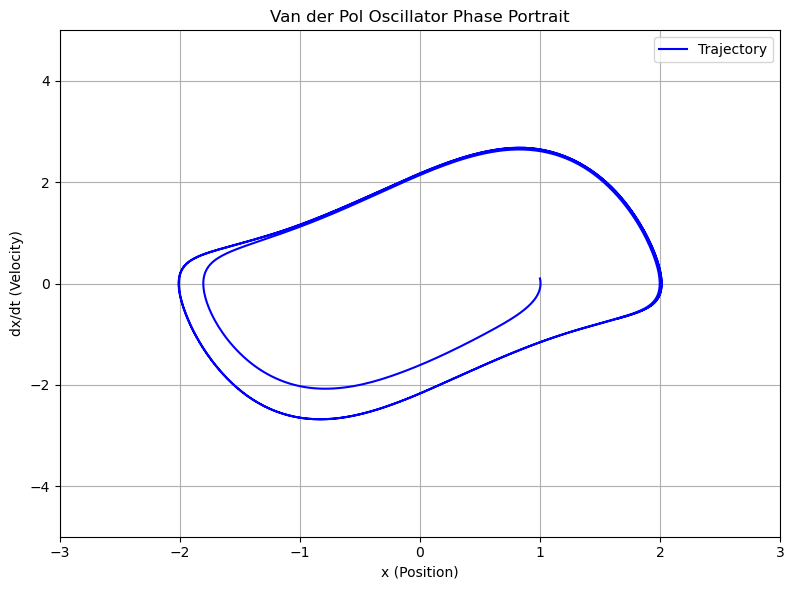

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def van_der_pol(t, y, mu):
    x, dx = y
    return [dx, mu * (1 - x**2) * dx - x]

mu = 1.0                       
y0 = [1.0, 0.1]                   
t_span = (0, 20)                   
t_eval = np.linspace(*t_span, 1000)  

solution = solve_ivp(van_der_pol, t_span, y0, args=(mu,), t_eval=t_eval)

x = solution.y[0]
y = solution.y[1]

# Plot phase portrait
plt.figure(figsize=(8, 6))
plt.plot(x, y, color='blue', lw=1.5, label="Trajectory")
plt.title("Van der Pol Oscillator Phase Portrait")
plt.xlabel("x (Position)")
plt.ylabel("dx/dt (Velocity)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim(-3, 3)
plt.ylim(-5, 5)
plt.show()


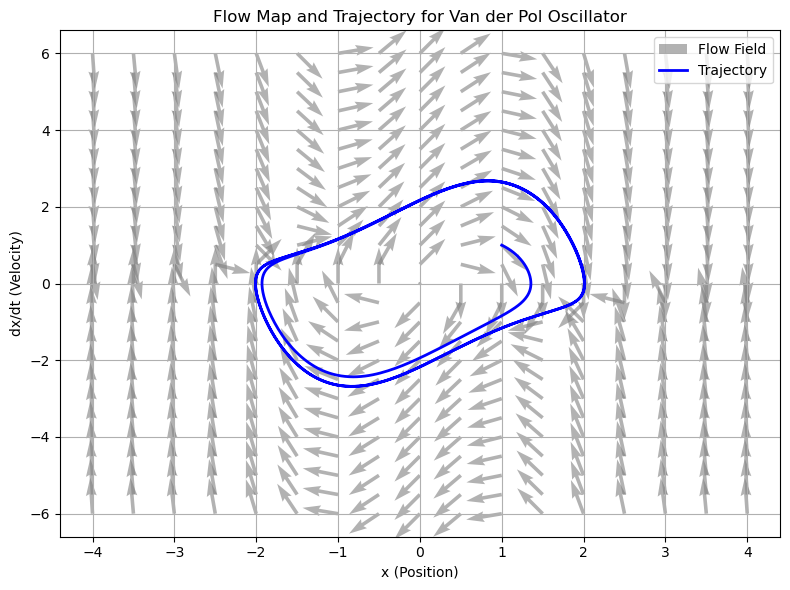

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def van_der_pol(t, y, mu):
    x, dx = y
    return [dx, mu * (1 - x**2) * dx - x]

mu = 1.0

x_vals = np.arange(-4, 4.1, 0.5)
dx_vals = np.arange(-6, 6.1, 0.5)
X, DX = np.meshgrid(x_vals, dx_vals)

DXU = DX
DYU = mu * (1 - X**2) * DX - X

magnitude = np.sqrt(DXU**2 + DYU**2) + 1e-6
DXU_norm = DXU / magnitude
DYU_norm = DYU / magnitude

y0 = [1.0, 1.0]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

solution = solve_ivp(van_der_pol, t_span, y0, args=(mu,), t_eval=t_eval)
x = solution.y[0]
dx = solution.y[1]

plt.figure(figsize=(8, 6))
plt.quiver(X, DX, DXU_norm, DYU_norm, scale=20, width=0.005, color='gray', alpha=0.6, label='Flow Field')
plt.plot(x, dx, color='blue', lw=2, label='Trajectory')
plt.title("Flow Map and Trajectory for Van der Pol Oscillator")
plt.xlabel("x (Position)")
plt.ylabel("dx/dt (Velocity)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
